### **openslr-52-asr-sinhala**

## 0. Setup

All external, non-stdlib packages this notebook needs, installed up front so every later
cell can assume they're present rather than failing partway through a long run.

In [ ]:
!pip install -q pandas numpy soundfile tqdm matplotlib torch torchaudio

## 1. Load the dataset

OpenSLR-52 ships differently from the other corpora: instead of Parquet shards with embedded
audio bytes, it is a TSV index (`utt_spk_text.tsv`, columns `file_id`, `speaker_id`, `transcript`)
plus a directory tree of standalone `.flac` files (`data/<first-two-hex-chars>/<file_id>.flac`).
There is no upstream train/val/test split and no embedded audio — every downstream step has to
resolve `file_id` to a path on disk first.

**Expect:** ~155,970 rows x 3 columns from the TSV, and ~185,293 `.flac` files on disk (the
directory holds more audio than the TSV references — see the reconciliation step below).

In [ ]:
import pandas as pd

df = pd.read_csv(
    "openslr_52/asr_sinhala/utt_spk_text.tsv",
    sep="\t",
    header=None,
    names=["file_id", "speaker_id", "transcript"],
)
print(df.shape)

### Inspect the raw structure

A quick look at the first rows to confirm what each column actually contains before we trust it.

In [ ]:
df.head(5)

,file_id,speaker_id,transcript
0,0000f47c22,7ab05,මහවැලි ගඟට ගොස් ආපසු එන ගමනේදී
1,000101700f,44e28,උන්වහන්සේ කපාපු
2,000107b539,b1a64,එය එතනින් අවසන් නොවී
3,00016825d3,2fff2,සිතින් අයහපතෙහි හැසිරීම නිසයි.
4,000171b8fd,d6ccd,එවන් ශ්‍රේෂ්ඨ ජාතියක් බිහි කිරීමට


## 2. Basic inventory

Total utterances, missing transcripts, and the speaker breakdown implied by the `speaker_id`
column — the counts that frame everything downstream.

In [ ]:
print("Total utterances:", len(df))
print("Unique speakers:", df["speaker_id"].nunique())
print("missing transcripts:", df["transcript"].isnull().sum())

Total utterances: 155970
Unique speakers: 478
missing transcripts: 0


### Transcript length distribution

Character counts per transcript. On its own this is a sanity check, but it becomes the numerator
of the chars-per-second ratio further down, our main misalignment detector.

A minimum near zero means empty/stub transcripts; a very large maximum matters because Whisper's
decoder caps at 448 tokens, and Sinhala tokenizes inefficiently under Whisper's BPE. A maximum in
the tens of thousands of characters is a red flag for a parsing error (e.g. an unescaped tab or
newline inside a transcript field merging multiple TSV rows into one) rather than a genuinely long
utterance, and is worth inspecting directly.

In [ ]:
df["text_len"] = df["transcript"].str.len()
df["text_len"].describe()

count    155970.000000
mean         34.074521
std         799.167146
min           2.000000
25%          18.000000
50%          24.000000
75%          32.000000
max      156305.000000
Name: text_len, dtype: float64

In [ ]:
# Inspect the longest "transcript" directly -- a value in the thousands of characters
# usually means a TSV parsing artefact (embedded tab/newline) rather than real speech.
print(df.loc[df["text_len"].idxmax(), "transcript"][:500])

මල්ලි තව ටික දුරකින් කලුතර බෝධිය
8fa1878f23	c11e1	මෙම ත්‍රිපිටක පොත් වහන්සේ අයත් වන්නේ ඛුද්දක නිකායටයි.
8fa1b262aa	3386d	නමුත් ඒ සුවිශේෂී ක්‍රමය
8fa2acc978	cb1fe	සුහදත්වය ගැන ප්‍රශ්නයක් වෙනවා උබෙයි මගෙයි .
8fa2c172ba	781ce	තෑන්ක්ස් සහෝ බොහොම ස්තූතියි සබ් වලට
8fa3c46f7d	880bc	සමාජ චාරිත්‍රයක් වශයෙනි
8fa403d570	8af08	අභිධර්මය තුළ හඳුන්වා දී ඇත්තේ
8fa4c4ec34	9125c	ලිප ගිනි මොලවනවා
8fa4d4a3ea	c2201	miss sri lanka 2011
8fa5cfc008	f5954	ඔය නිකාබ් බුර්කා ඇඳිල්ල
8fa621b26c	9d5b3	උබ වගේ පොල් බුරුවෙක්ට
8f


## 3. Reconciling the TSV against the audio directory

Unlike the Parquet-based corpora, OpenSLR's audio and transcripts live in two independent
places that can silently drift apart: the TSV can reference a `file_id` with no matching `.flac`
on disk, and the directory can contain `.flac` files that were never listed in the TSV at all
(unlabeled audio, useless for supervised training). Both directions need checking before assuming
`len(df)` is the usable dataset size.

In [ ]:
import os
import glob

DATA_DIR = "openslr_52/asr_sinhala/data/"

all_audio_paths = glob.glob(os.path.join(DATA_DIR, "**", "*.flac"), recursive=True)
audio_path_map = {
    os.path.splitext(os.path.basename(p))[0]: p
    for p in all_audio_paths
}
print(f"Total audio files found on disk: {len(all_audio_paths)}")

In [ ]:
tsv_ids = set(df["file_id"])
audio_ids = set(audio_path_map.keys())

missing_audio = tsv_ids - audio_ids       # transcribed but no audio file present
untranscribed = audio_ids - tsv_ids       # audio on disk with no TSV row at all

print(f"Audio files in TSV: {len(tsv_ids)}")
print(f"Audio files found in directory: {len(all_audio_paths)}")
print(f"TSV rows with no matching audio file: {len(missing_audio)}")
print(f"Audio files on disk with no transcript: {len(untranscribed)}")
print("Sample untranscribed IDs:", list(untranscribed)[:10])

Audio files in TSV: 155970
Audio files found in directory: 185293
TSV rows with no matching audio file: 0
Audio files on disk with no transcript: 29323
Sample untranscribed IDs: ['3a6ecea000', '9c62c9e1d0', '8b6a3a92bf', '167cc1b28b', '7a5c5fc86e', '1768d66893', '8ff366b112', '766b404865', '8a6ec9dafa', '2ce7038347']


In [ ]:
# Drop TSV rows that have nowhere to read audio from -- everything downstream needs a real path.
if missing_audio:
    df = df[~df["file_id"].isin(missing_audio)].reset_index(drop=True)
print("Usable rows after reconciliation:", len(df))

Usable rows after reconciliation: 155970


## 4. Duration extraction

`sf.info()` reads only the file header — sample rate, frame count, channels — so duration comes
essentially for free without decoding the full waveform.

In [10]:
import soundfile as sf

def get_duration(file_id):
    path = audio_path_map.get(file_id)
    if path is None:
        return None
    try:
        return sf.info(path).duration
    except Exception:
        return None

df["duration"] = df["file_id"].apply(get_duration)
df["duration"].describe()

count    155970.000000
mean          4.362069
std           1.605085
min           1.100000
25%           3.300000
50%           4.000000
75%           5.000000
max          30.700000
Name: duration, dtype: float64

### Listen to the longest clip

The single most informative clip to audition manually — if anything breaches the 30 s Whisper
encoder window or carries a truncated transcript, it will be this one.

In [11]:
from IPython.display import Audio, display

row = df.loc[df["duration"].idxmax()]
display(Audio(audio_path_map[row["file_id"]]))
print(row["duration"], "sec")
print(row["transcript"])

30.7 sec
මං සංගිත නර්තන චිත්‍ර තෙවිශයටම කරලා තියෙන්නෙ අපරමාන එකෙත් හොදම එකක් නෙව! උත්සහා කරන්න.තව මොනවා හරි කරන්න.


## **Transcript-audio alignment issues**

### Characters per second

`len(text) / duration` should cluster tightly for genuine speech. Rows outside the band are
almost always broken pairs rather than unusual speakers — too high means more text than the audio
could plausibly contain, too low means a truncated transcript or a mostly-silent/noisy clip.

The 2–30 thresholds are calibrated to Sinhala script; read the printed distribution and cut in the
tails rather than trusting numbers imported from another dataset.

In [12]:
df["chars_per_sec"] = df["transcript"].str.len() / df["duration"]
print(df["chars_per_sec"].describe())

suspicious = df[(df["chars_per_sec"] > 30) | (df["chars_per_sec"] < 2)]
print(f"Suspicious rows: {len(suspicious)} of {len(df)}")

def play(idx):
    row = df.loc[idx]
    print(f"[{idx}] {row['duration']:.2f}s | {row['chars_per_sec']:.1f} chars/sec")
    print(row["transcript"])
    display(Audio(audio_path_map[row["file_id"]]))

if len(suspicious):
    play(suspicious["chars_per_sec"].idxmax())

count    155970.000000
mean          7.943025
std         168.178338
min           0.316901
25%           4.677419
50%           6.000000
75%           7.407407
max       30715.333333
Name: chars_per_sec, dtype: float64
Suspicious rows: 1570 of 155970
[54418] 4.50s | 30715.3 chars/sec
අධිකරණ තීන්දුව පිළිබඳව
556e69bec3	5b275	ගොස් නතර වූ බව පැවසෙනවා.
556e6e3adf	c094f	එබැවින් නිවැරැදි ව
556e70894a	bd2b2	ඒ ගොඩනැගිල්ල වටේ එතුවා.
556e758731	e47dc	ඉතාම කාලෝචිත බොරු ගොඩක්හී
556ed44818	f5954	එජාපයේ තනතුරු දරමින්
556f672d3c	f200a	එහිදී එයට ගෝචර වන පුද්ගලයා
556f6e8935	4a53b	විනය නොනැසෙන පරිදි ආරක්ෂා කිරීම
556fd560cc	81570	එකම මවගේ දරුවන් ලෙස ඉතාමත් සුහදව
556fda7817	bfb80	විශේෂයෙන්ම මහජන සෞඛ්‍ය සේවාවල
5571014910	e8724	පහසුකම් ඉතා අඩු ආවාසයකි.
55711e2408	0bd84	එම ගම්වැසියන් කියූ කතාවක්
557176d22f	12204	ඊට පස්සෙ තැපැල් ස්ථානාධිපතිවරු දුම්රිය ස්ථානාධිපති වගේ තනතුරු
5571d14e4f	e8724	එකම ප්‍රයෝජනය
5571fd254b	5afae	ප්‍රයෝජනයක් නැහැ
55720d1f08	91fdf	ඉස්සරහ ඉන්න කෙනාගේ ඔලුවේ රතු තොප්පියක් තිබුන නම්
557299

## **Empty or garbage transcripts**

### Empty and stub transcripts

An empty transcript paired with real speech is the worst training example possible — it teaches
the model that speech maps to nothing. Stub transcripts under a few characters are the milder
version and worth auditioning before deciding fix vs. drop.

In [13]:
text = df["transcript"].fillna("").str.strip()

empty_text = df[text == ""]
very_short_text = df[(text != "") & (text.str.len() < 3)]

print(f"Empty/whitespace: {len(empty_text)}")
print(f"Very short (<3 chars): {len(very_short_text)}")

Empty/whitespace: 0
Very short (<3 chars): 16


In [14]:
# Placeholder labels some ASR/annotation pipelines insert for clips they couldn't transcribe --
# these read as real text (non-empty) but carry no usable transcript.
PLACEHOLDER_PATTERNS = [
    "audio not suitable for transcription",
    "transcription not found",
    "unable to transcribe",
]

text_lower = df["transcript"].fillna("").str.strip().str.lower()
not_found = df[text_lower.isin(PLACEHOLDER_PATTERNS)]

print(f"Rows with a 'not suitable for transcription' placeholder: {len(not_found)}")
display(not_found[["file_id", "transcript"]])

Rows with a 'not suitable for transcription' placeholder: 0


,file_id,transcript


## **Duplicates**

### Duplicate transcripts

Duplicates over-weight whatever they contain and, since OpenSLR-52 carries no upstream
train/val/test split, are the main leakage risk once we cut our own splits downstream.

In [15]:
text = df["transcript"].fillna("").str.strip()

dup_mask = text.duplicated(keep=False) & (text != "")
print(f"Rows with a duplicated transcript: {dup_mask.sum()}")

dup_groups = df[dup_mask].groupby(text[dup_mask])["file_id"].apply(list)
print(f"Distinct duplicated transcripts: {len(dup_groups)}")

for t, ids in list(dup_groups.items())[:3]:
    print(f"\n--- {t[:120]}")
    print(df[df['file_id'].isin(ids)][["file_id", "duration", "chars_per_sec"]].to_string())

Rows with a duplicated transcript: 104262
Distinct duplicated transcripts: 42267

--- ' පෝරකයට නංවා ගෙලට තොණ්ඩුව දැමීමෙන්ද පසුව
           file_id  duration  chars_per_sec
50281   4f5693d1e1       5.6       7.321429
155244  feece35157       5.9       6.949153

--- ''කැළණි පාලම''යි.
          file_id  duration  chars_per_sec
11172  10b5aa5975       2.8       6.071429
67663  6c4010f475       2.5       6.800000

--- ''තාත්තා කෝ'' යයි
          file_id  duration  chars_per_sec
36703  3b42ae46a6       6.6       2.575758
39850  403b0300be       3.7       4.594595


In [16]:
N_GROUPS = 5  # how many duplicate-transcript groups to audition

for t, ids in list(dup_groups.items())[:N_GROUPS]:
    print(f"\n=== Transcript: {t}")
    print(f"File IDs sharing this transcript: {ids}\n")
    for fid in ids:
        print(f"file_id: {fid}")
        display(Audio(audio_path_map[fid]))


=== Transcript: ' පෝරකයට නංවා ගෙලට තොණ්ඩුව දැමීමෙන්ද පසුව
File IDs sharing this transcript: ['4f5693d1e1', 'feece35157']

file_id: 4f5693d1e1


file_id: feece35157



=== Transcript: ''කැළණි පාලම''යි.
File IDs sharing this transcript: ['10b5aa5975', '6c4010f475']

file_id: 10b5aa5975


file_id: 6c4010f475



=== Transcript: ''තාත්තා කෝ'' යයි
File IDs sharing this transcript: ['3b42ae46a6', '403b0300be']

file_id: 3b42ae46a6


...

file_id: 0b44949ff4


file_id: 258daafafc



=== Transcript: 'ඉතිහාස කතා වෙළෙන්දෝ' කිසිවකුටත්
File IDs sharing this transcript: ['389d20c29c', 'c77a2f54fa', 'e444937f14']

file_id: 389d20c29c


file_id: c77a2f54fa


file_id: e444937f14


## **Non-target-language contamination**

### Language contamination

Fraction of each transcript's non-whitespace characters that fall inside the Sinhala Unicode
block (U+0D80–U+0DFF). Some Latin script (code-switching) is expected and fine; `sinhala_ratio == 0`
is the degenerate case worth flagging — a wrong-language row or placeholder rather than real
code-switching.

In [17]:
import re

SINHALA = re.compile(r'[\u0D80-\u0DFF]')
text = df["transcript"].fillna("")

df["sinhala_ratio"] = text.apply(
    lambda t: len(SINHALA.findall(t)) / max(len(re.sub(r'\s', '', t)), 1)
)

no_sinhala = df[df["sinhala_ratio"] == 0]
mostly_latin = df[(df["sinhala_ratio"] > 0) & (df["sinhala_ratio"] < 0.3)]

print(f"No Sinhala at all: {len(no_sinhala)}")
print(f"Mostly non-Sinhala (<30%): {len(mostly_latin)}")
print(df.loc[no_sinhala.index, ["file_id", "transcript"]].head(10).to_string())

No Sinhala at all: 5750
Mostly non-Sinhala (<30%): 0
        file_id                               transcript
5    00018c30ff                              day offices
34   000ab89be5                     magazines of the 90s
37   000bb8ae7d                                  android
60   00150b06a3            windows xp service pack 3 sp3
90   0021fa324d  full hindi movies with sinhala subtitle
93   0024b4aac4                      election department
100  0027c33491             world trade center sri lanka
117  002e2b91a8                                nokla 525
160  003a027c8b                                ethiopian
174  003d81317a                      harappa civiliation


## 5. Audio header probe

A second pass over the audio, recording sample rate, channel count, subtype, container format,
and byte size. Errors are captured per-row into an `error` column instead of raised, so one
corrupt file doesn't abort the whole pass. Whisper requires 16 kHz mono, so this is also where
format compliance gets checked.

In [18]:
from tqdm.auto import tqdm

rows = []
for fid in tqdm(df["file_id"], desc="headers"):
    r = {"file_id": fid, "error": None}
    try:
        path = audio_path_map[fid]
        r["n_bytes"] = os.path.getsize(path)
        info = sf.info(path)
        r.update(sr=info.samplerate, channels=info.channels, subtype=info.subtype,
                 fmt=info.format, frames=info.frames,
                 duration=info.frames / info.samplerate)
    except Exception as e:
        r["error"] = f"{type(e).__name__}: {e}"
    rows.append(r)

meta = pd.DataFrame(rows).set_index("file_id")
meta = df.set_index("file_id")[["transcript"]].join(meta)
print("unreadable:", meta.error.notna().sum())
display(meta[meta.error.notna()].head())
meta.head()

/home/yohan-jayasinghe/WhisperSL/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
headers: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 155970/155970 [00:07<00:00, 19514.79it/s]


unreadable: 0


,transcript,error,n_bytes,sr,channels,subtype,fmt,frames,duration
file_id,,,,,,,,,


,transcript,error,n_bytes,sr,channels,subtype,fmt,frames,duration
file_id,,,,,,,,,
0000f47c22,මහවැලි ගඟට ගොස් ආපසු එන ගමනේදී,None,94551,16000,1,PCM_16,FLAC,89600,5.6
000101700f,උන්වහන්සේ කපාපු,None,58952,16000,1,PCM_16,FLAC,46400,2.9
000107b539,එය එතනින් අවසන් නොවී,None,46213,16000,1,PCM_16,FLAC,44800,2.8
00016825d3,සිතින් අයහපතෙහි හැසිරීම නිසයි.,None,104232,16000,1,PCM_16,FLAC,88000,5.5
000171b8fd,එවන් ශ්‍රේෂ්ඨ ජාතියක් බිහි කිරීමට,None,58924,16000,1,PCM_16,FLAC,51200,3.2


### Duration statistics

Total hours is the number that should shape the training recipe. `over_30s` is the actionable
column: anything over 30 s would be truncated against a full transcript, and sub-0.5 s clips are
usually fragments.

In [19]:
ok = meta[meta.error.isna()].copy()

overall = pd.Series({
    "n_clips": len(ok),
    "hours":   ok.duration.sum()/3600,
    "min_s":   ok.duration.min(),
    "p50_s":   ok.duration.quantile(.50),
    "p95_s":   ok.duration.quantile(.95),
    "p99_s":   ok.duration.quantile(.99),
    "max_s":   ok.duration.max(),
    "mean_s":  ok.duration.mean(),
}).round(2)
display(overall.to_frame("openslr"))

print(f"clips exceeding Whisper's 30 s window: {(ok.duration > 30).sum()}")
print(f"clips under 0.5 s: {(ok.duration < 0.5).sum()}")

,openslr
n_clips,155970.00
hours,188.99
min_s,1.10
p50_s,4.00
p95_s,7.30
p99_s,10.00
max_s,30.70
mean_s,4.36


clips exceeding Whisper's 30 s window: 2
clips under 0.5 s: 0


### Format compliance

Groups every distinct (sample rate, channels, subtype, format) combination so any inconsistency
shows up immediately. Sample rate below 16 kHz is the critical row — it is not fixable, since
upsampling cannot restore frequency content never captured.

In [20]:
display(ok.groupby(["sr", "channels", "subtype", "fmt"]).size()
          .rename("count").reset_index().sort_values("count", ascending=False))

print("not 16 kHz:", (ok.sr != 16000).sum(), "->", sorted(ok.sr.unique().tolist()))
print("not mono  :", (ok.channels != 1).sum())
print("subtypes  :", ok.subtype.value_counts().to_dict())

low = ok[ok.sr < 16000]
if len(low):
    print(f"\n\u26a0 {len(low)} clips below 16 kHz ({low.duration.sum()/3600:.2f} h) "
          "-- band-limited; upsampling cannot recover this")

,sr,channels,subtype,fmt,count
0,16000,1,PCM_16,FLAC,155970


not 16 kHz: 0 -> [16000]
not mono  : 0
subtypes  : {'PCM_16': 155970}


## 6. Level, clipping, and silence analysis

The first pass that actually decodes the waveforms. `frame_rms` slices the signal into
overlapping 1024-sample windows (64 ms at 16 kHz) advancing 512 samples at a time, computing RMS
energy per window so we can locate *where* silence is, not just how loud the clip is overall.

| Metric | Meaning | Why it matters |
|---|---|---|
| `peak_dbfs` | loudest single sample | near 0 dBFS suggests clipping |
| `rms_dbfs` | average energy | overall loudness; big spreads mean inconsistent levels |
| `clip_frac` | fraction of samples at full scale | actual distortion, unrecoverable |
| `silence_frac` | fraction of frames below threshold | mostly-silent clips waste the encoder window |
| `lead_sil_s` | silence before first voiced frame | segmentation started too early |
| `trail_sil_s` | silence after last voiced frame | segmentation ended too late |

`SIL_DBFS = -45` is an *absolute* level, so a quietly recorded clip can register as mostly silent
even with continuous speech — which is exactly why the VAD cross-check in section 7 exists.

In [21]:
import numpy as np

SIL_DBFS, FRAME, HOP = -45.0, 1024, 512

def frame_rms(x):
    if len(x) < FRAME:
        return np.array([np.sqrt(np.mean(x**2) + 1e-12)])
    n = 1 + (len(x) - FRAME)//HOP
    idx = np.arange(FRAME)[None, :] + HOP*np.arange(n)[:, None]
    return np.sqrt(np.mean(x[idx]**2, axis=1) + 1e-12)

def analyse(path):
    x, sr = sf.read(path, dtype="float32", always_2d=True)
    x = x.mean(axis=1)
    d = len(x)/sr
    voiced = 20*np.log10(frame_rms(x)) > SIL_DBFS
    hop_s = HOP/sr
    if voiced.any():
        lead  = np.argmax(voiced) * hop_s
        trail = max(0.0, d - (len(voiced)-1-np.argmax(voiced[::-1])) * hop_s)
    else:
        lead = trail = d
    to_db = lambda v: 20*np.log10(max(float(v), 1e-10))
    return dict(peak_dbfs=to_db(np.abs(x).max()),
                rms_dbfs=to_db(np.sqrt(np.mean(x**2))),
                clip_frac=float((np.abs(x) >= .999).mean()),
                silence_frac=float((~voiced).mean()),
                lead_sil_s=float(lead), trail_sil_s=float(trail))

recs = []
for fid in tqdm(ok.index, desc="levels + silence"):
    try:
        recs.append({"file_id": fid, **analyse(audio_path_map[fid])})
    except Exception as e:
        recs.append({"file_id": fid, "err": str(e)})

lv = pd.DataFrame(recs).set_index("file_id").join(ok[["transcript", "duration"]])
lv.head()

levels + silence:  18%|██████████████████████████▌                                                                                                                       | 28369/155970 [00:41<03:11, 664.72it/s]

levels + silence: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 155970/155970 [03:48<00:00, 681.56it/s]


,peak_dbfs,rms_dbfs,clip_frac,silence_frac,lead_sil_s,trail_sil_s,transcript,duration
file_id,,,,,,,,
0000f47c22,-12.960828,-32.426537,0.0,0.568966,2.144,0.992,මහවැලි ගඟට ගොස් ආපසු එන ගමනේදී,5.6
000101700f,-2.955173,-20.176189,0.0,0.247191,0.416,0.148,උන්වහන්සේ කපාපු,2.9
000107b539,-24.697431,-42.104435,0.0,0.581395,1.216,0.368,එය එතනින් අවසන් නොවී,2.8
00016825d3,-8.189263,-27.910033,0.0,0.064706,0.000,0.092,සිතින් අයහපතෙහි හැසිරීම නිසයි.,5.5
000171b8fd,-11.567672,-31.510251,0.0,0.555556,1.184,0.608,එවන් ශ්‍රේෂ්ඨ ජාතියක් බිහි කිරීමට,3.2


### Level report and flagging

`near_silent` catches recordings that essentially failed; `very_quiet` catches level outliers that
are still usable; `clipped` catches distortion; `mostly_silence` and the lead/trail flags catch bad
segment boundaries. `n_flags` sums the conditions per clip so the worst offenders sort to the top.

,rms_dbfs,peak_dbfs,clip_frac,silence_frac,lead_sil_s,trail_sil_s
count,155970.00,155970.00,155970.0,155970.00,155970.00,155970.00
mean,-30.07,-11.23,0.0,0.50,1.10,0.81
std,6.74,7.21,0.0,0.17,0.89,0.57
min,-55.31,-36.85,0.0,0.00,0.00,0.06
5%,-41.47,-23.68,0.0,0.13,0.00,0.08
25%,-35.00,-16.67,0.0,0.42,0.70,0.47
50%,-29.77,-10.68,0.0,0.52,0.96,0.77
75%,-24.68,-5.01,0.0,0.62,1.31,1.08
95%,-19.78,-1.44,0.0,0.75,2.59,1.66
max,-15.34,0.00,0.0,1.00,20.38,21.27


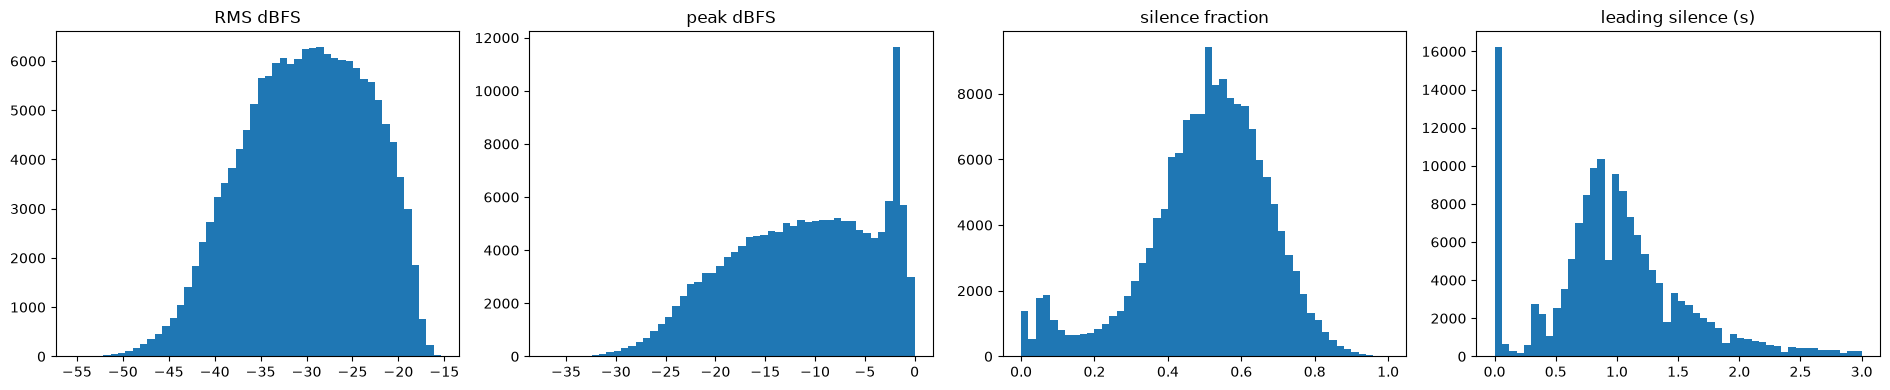

,n_clips
near_silent,128
very_quiet,21249
clipped,1
mostly_silence,45719
long_lead_sil,29142
long_trail_sil,12382


,duration,rms_dbfs,clip_frac,silence_frac,lead_sil_s,n_flags
file_id,,,,,,
95890d7703,7.4,-42.461256,0.0,0.843478,1.920,4
543dbcc2a1,5.5,-38.806399,0.0,0.847059,1.504,4
f44906edf6,5.9,-38.827061,0.0,0.743169,2.144,4
29fdd32016,4.2,-53.314933,0.0,0.938462,1.536,4
db57dc4b92,6.9,-38.041017,0.0,0.785047,2.368,4
8f32cf8e25,7.6,-42.957112,0.0,0.656780,3.072,4
9d47d7f716,9.4,-47.939628,0.0,0.787671,4.320,4
c4afe0635e,5.9,-38.044059,0.0,0.693989,1.696,4
a1bab5a6b0,9.9,-40.936319,0.0,0.665584,3.456,4


In [22]:
import matplotlib.pyplot as plt

cols = ["rms_dbfs", "peak_dbfs", "clip_frac", "silence_frac", "lead_sil_s", "trail_sil_s"]
display(lv[cols].describe(percentiles=[.05, .25, .5, .75, .95]).round(2))

fig, ax = plt.subplots(1, 4, figsize=(19, 4))
ax[0].hist(lv.rms_dbfs.dropna(), bins=50);              ax[0].set_title("RMS dBFS")
ax[1].hist(lv.peak_dbfs.dropna(), bins=50);             ax[1].set_title("peak dBFS")
ax[2].hist(lv.silence_frac.dropna(), bins=50);          ax[2].set_title("silence fraction")
ax[3].hist(lv.lead_sil_s.dropna(), bins=50, range=(0,3)); ax[3].set_title("leading silence (s)")
plt.tight_layout(); plt.show()

flags = pd.DataFrame({
    "near_silent":    lv.rms_dbfs < -50,
    "very_quiet":     lv.rms_dbfs.between(-50, -38),
    "clipped":        lv.clip_frac > .001,
    "mostly_silence": lv.silence_frac > .60,
    "long_lead_sil":  lv.lead_sil_s > 1.5,
    "long_trail_sil": lv.trail_sil_s > 1.5,
})
display(flags.sum().to_frame("n_clips"))

lv["n_flags"] = flags.sum(axis=1)
display(lv.sort_values("n_flags", ascending=False)
          .head(15)[["duration", "rms_dbfs", "clip_frac",
                     "silence_frac", "lead_sil_s", "n_flags"]])

### Audition the worst offenders

The flags detect *signal* problems; the ear detects *label* problems, which hurt WER more. Play
the six highest-`n_flags` clips with their transcripts printed alongside.

In [23]:
def play_fid(fid):
    x, sr = sf.read(audio_path_map[fid], dtype="float32", always_2d=True)
    print(f"[{fid}] {sr} Hz | {len(x)/sr:.2f}s")
    print(lv.at[fid, "transcript"][:300])
    display(Audio(x.mean(axis=1), rate=sr))

for fid in lv.sort_values("n_flags", ascending=False).index[:6]:
    play_fid(fid)
    print("-" * 80)

[95890d7703] 16000 Hz | 7.40s
උබ සිංහලයෙක්ද


--------------------------------------------------------------------------------
[543dbcc2a1] 16000 Hz | 5.50s
එහෙම ඕන නම්


--------------------------------------------------------------------------------
[f44906edf6] 16000 Hz | 5.90s
ඔහු එකපාරටම


--------------------------------------------------------------------------------
[29fdd32016] 16000 Hz | 4.20s
දක්නට ලැබිණි


--------------------------------------------------------------------------------
[db57dc4b92] 16000 Hz | 6.90s
ඊට එරෙහි ව ඩෝල් සමාගම


--------------------------------------------------------------------------------
[8f32cf8e25] 16000 Hz | 7.60s
එතකොට මහා නායක හාමුදුරුවො මුණගැහිල එනකොටත්


--------------------------------------------------------------------------------


---

# 7. Cross-checking silence with VAD

The energy pass above decides "silence" from a single absolute threshold (`-45 dBFS`), which
measures **loudness**, not **speech** — a quiet but intelligible clip can register as mostly
silent, and steady background noise can register as voiced.

We use **Silero VAD**, a small neural detector (via `torch.hub`) that decides speech from learned
spectral structure rather than raw level, so it fails in genuinely different ways. Agreement between
the two methods means the measurement can be trusted; disagreement gives a shortlist of clips worth
listening to.

### 7.1 VAD-based silence measurement

Silero VAD returns speech **timestamps** directly, so there is no manual framing or smoothing
step. From the timestamps we derive the same quantities as the energy pass, plus segment count and
an overall speech percentage.

In [ ]:
import torch
import torchaudio

# torch.hub's fork-validation call to the GitHub API can get rate-limited when unauthenticated
# and crash on a missing header; skip that check.
import torch.hub
torch.hub._validate_not_a_forked_repo = lambda a, b, c: True

silero_model, silero_utils = torch.hub.load(
    "snakers4/silero-vad", "silero_vad", trust_repo=True
)
get_speech_timestamps = silero_utils[0]


def vad_analyse(path):
    x, sr = sf.read(path, dtype="float32", always_2d=True)
    x = x.mean(axis=1)
    dur = len(x) / sr

    wav = torch.from_numpy(x)
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)

    ts = get_speech_timestamps(wav, silero_model, sampling_rate=16000, return_seconds=True)

    if not ts:
        return dict(vad_silence_frac=1.0, vad_lead_sil_s=dur,
                    vad_trail_sil_s=dur, vad_speech_s=0.0, vad_n_segments=0)

    speech_s = sum(t["end"] - t["start"] for t in ts)

    return dict(
        vad_silence_frac = max(0.0, 1 - speech_s / dur),
        vad_lead_sil_s   = ts[0]["start"],
        vad_trail_sil_s  = max(0.0, dur - ts[-1]["end"]),
        vad_speech_s     = speech_s,
        vad_n_segments   = len(ts),
    )


vrecs = []
for fid in tqdm(ok.index, desc="VAD"):
    try:
        vrecs.append({"file_id": fid, **vad_analyse(audio_path_map[fid])})
    except Exception as e:
        vrecs.append({"file_id": fid, "vad_err": str(e)})

vad_df = pd.DataFrame(vrecs).set_index("file_id")
print("VAD failures:", vad_df.get("vad_err", pd.Series(dtype=object)).notna().sum())
vad_df.head()

Using cache found in /home/yohan-jayasinghe/.cache/torch/hub/snakers4_silero-vad_master
VAD:   1%|██▎                                                                                                                                                            | 2247/155970 [00:55<1:01:35, 41.60it/s]

VAD:   2%|███▊                                                                                                                                                           | 3729/155970 [01:32<1:00:34, 41.89it/s]

### 7.2 Compare the two methods

Joining the VAD results onto `lv` and computing the per-clip difference between the two
estimates. Correlation near 1.0 means the methods agree; a consistent bias means the `-45 dBFS`
threshold is mis-set for this corpus; high spread with low bias means individual clips genuinely
need auditioning.

In [ ]:
cmp = lv.join(vad_df)

cmp["d_silence"] = cmp.vad_silence_frac - cmp.silence_frac
cmp["d_lead"]    = cmp.vad_lead_sil_s   - cmp.lead_sil_s
cmp["d_trail"]   = cmp.vad_trail_sil_s  - cmp.trail_sil_s

pairs = [("silence_frac", "vad_silence_frac"),
         ("lead_sil_s",   "vad_lead_sil_s"),
         ("trail_sil_s",  "vad_trail_sil_s")]

print("energy vs VAD\n" + "-"*58)
for e, v in pairs:
    s = cmp[[e, v]].dropna()
    print(f"{e:>14} | r={s[e].corr(s[v]):+.3f}  "
          f"mean {s[e].mean():6.3f} -> {s[v].mean():6.3f}  "
          f"bias {(s[v]-s[e]).mean():+.3f}  |diff| p95 {(s[v]-s[e]).abs().quantile(.95):.3f}")

display(cmp[["silence_frac", "vad_silence_frac", "d_silence",
             "lead_sil_s", "vad_lead_sil_s", "d_lead",
             "trail_sil_s", "vad_trail_sil_s", "d_trail"]]
        .describe(percentiles=[.05, .5, .95]).round(3))

### 7.3 Visualise the agreement

Points tight on the diagonal mean agreement; a cloud above means VAD finds more silence than
energy (noise counted as speech); a cloud below means VAD finds less (quiet speech counted as
silence).

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4.5))

for a, (e, v, t) in zip(ax, [
    ("silence_frac", "vad_silence_frac", "silence fraction"),
    ("lead_sil_s",   "vad_lead_sil_s",   "leading silence (s)"),
    ("trail_sil_s",  "vad_trail_sil_s",  "trailing silence (s)"),
]):
    s = cmp[[e, v]].dropna()
    a.scatter(s[e], s[v], s=8, alpha=.35)
    lim = max(s[e].max(), s[v].max()) * 1.05
    a.plot([0, lim], [0, lim], "r--", lw=1)
    a.set_xlim(0, lim); a.set_ylim(0, lim)
    a.set_xlabel(f"energy  {e}"); a.set_ylabel(f"VAD  {v}"); a.set_title(t)

energy_speech = cmp.duration * (1 - cmp.silence_frac)
ax[3].hist((cmp.vad_speech_s - energy_speech).dropna(), bins=60)
ax[3].axvline(0, color="r", ls="--", lw=1)
ax[3].set_title("VAD speech - energy speech (s)")
ax[3].set_xlabel("seconds")

plt.tight_layout(); plt.show()

### 7.4 Disagreement flags and audition

| Flag | Condition | Interpretation |
|---|---|---|
| `energy_missed_noise` | VAD says silent, energy said voiced | Background noise above threshold |
| `energy_over_trimmed` | VAD says voiced, energy said silent | Quiet speech below threshold |
| `vad_no_speech` | VAD finds no speech at all | Strong candidate for an empty/noise-only clip |
| `very_fragmented` | many separate speech segments | Long internal pauses or merged utterances |
| `vad_speech_too_short` | under 1 s of speech total | Too little content for a 30 s encoder window |

**Listen to these before changing any threshold** — the numbers tell you the two methods
disagree, but only the audio tells you which one is right.

In [ ]:
vflags = pd.DataFrame({
    "energy_missed_noise":  (cmp.d_silence >  0.15),
    "energy_over_trimmed":  (cmp.d_silence < -0.15),
    "lead_disagree_0.5s":   (cmp.d_lead.abs()  > 0.5),
    "trail_disagree_0.5s":  (cmp.d_trail.abs() > 0.5),
    "vad_no_speech":        (cmp.vad_speech_s == 0),
    "vad_speech_too_short": (cmp.vad_speech_s < 1.0),
    "very_fragmented":      (cmp.vad_n_segments > 8),
})
display(vflags.sum().to_frame("n_clips"))

cmp["disagreement"] = (cmp.d_silence.abs() + cmp.d_lead.abs()/10 + cmp.d_trail.abs()/10)

print("\nMost contested clips -- listen before trusting either method:")
display(cmp.sort_values("disagreement", ascending=False)
           .head(15)[["duration", "rms_dbfs",
                      "silence_frac", "vad_silence_frac", "d_silence",
                      "lead_sil_s", "vad_lead_sil_s",
                      "vad_n_segments", "disagreement"]].round(3))

In [ ]:
for fid in cmp.sort_values("disagreement", ascending=False).index[:6]:
    r = cmp.loc[fid]
    print(f"[{fid}] {r.duration:.2f}s | RMS {r.rms_dbfs:.1f} dBFS")
    print(f"    energy: silence {r.silence_frac:.2f}  lead {r.lead_sil_s:.2f}s  trail {r.trail_sil_s:.2f}s")
    print(f"    VAD   : silence {r.vad_silence_frac:.2f}  lead {r.vad_lead_sil_s:.2f}s  "
          f"trail {r.vad_trail_sil_s:.2f}s  segments {int(r.vad_n_segments)}")
    play_fid(fid)
    print("-" * 80)

In [ ]:
# Clips Silero VAD found no speech in at all (vad_no_speech), or under 1s of speech
# (vad_speech_too_short) -- listen to confirm they're genuinely silent/noise rather than
# missed quiet speech.
silent_clips = cmp[vflags["vad_no_speech"] | vflags["vad_speech_too_short"]]
print(f"VAD-silent clips: {len(silent_clips)}")

for fid in silent_clips.index:
    r = cmp.loc[fid]
    print(f"[{fid}] {r.duration:.2f}s | RMS {r.rms_dbfs:.1f} dBFS | "
          f"vad_speech_s={r.vad_speech_s:.2f}s | energy silence_frac={r.silence_frac:.2f}")
    print(r.transcript[:300])
    play_fid(fid)
    print("-" * 80)

---

## 8. What this tells us, and what comes next

1. **Reconciliation** — the TSV and the audio directory disagree in both directions; only rows
   with a matching, readable audio file are usable.
2. **Format** — confirm every clip is 16 kHz mono; if so, no resampling step is needed.
3. **Duration** — check for clips approaching or exceeding the 30 s window; filter or truncate-flag
   those explicitly.
4. **Transcript integrity** — use the chars-per-second, empty-text, duplicate, and language checks
   above as a shortlist to fix or drop. Fix where the audio is intact.
5. **Silence and level** — the energy-versus-VAD comparison decides whether a trimming step is
   needed, and which measurement should drive it.

Before training: verify no transcript exceeds Whisper's 448-token decoder limit after
tokenisation, decide train/val/test splits (none exist upstream for this corpus), and evaluate
un-fine-tuned `whisper-small` on a held-out slice to get a baseline WER.